# Payment Fraud Risk Scoring on Imbalanced Transaction Data

**Goal:** rank card transactions by fraud risk so a fraud-operations team can
review the riskiest ones first, under a severe class imbalance (fraud ≈ 0.17%).

This notebook is a compact, end-to-end applied-ML walkthrough:

1. Problem statement & why the usual metrics fail here
2. Data loading
3. Exploratory analysis (imbalance + key feature distributions)
4. Preprocessing & a stratified train / validation / test split
5. Baseline — **Logistic Regression**
6. Tree ensemble — **Random Forest**
7. Gradient boosting — **XGBoost** and **LightGBM**
8. Imbalance handling — **class weights**, **threshold tuning**, optional **SMOTE**
9. Evaluation — **PR-AUC, Recall, Precision, F1, confusion matrix, Precision@K**
10. Model comparison & a final recommendation
11. A simple, reusable **risk-scoring inference** bundle

All randomness is seeded for reproducibility. Modelling/plotting logic that is
reused lives in the `src/` package (`src.data`, `src.scoring`); the notebook
stays focused on narrative and results.

## 1. Problem statement

A fraud-scoring model assigns each transaction a probability of being
fraudulent. In production these scores feed a **review queue**: analysts (or an
auto-block rule) handle the highest-risk transactions first.

The dataset is the public **Credit Card Fraud Detection** set (ULB / Kaggle,
`mlg-ulb/creditcardfraud`): 284,807 real European card transactions over two
days in September 2013, of which only **492 (0.173%) are fraud**. Features
`V1`–`V28` are PCA components published in place of the raw (confidential)
fields; `Time` and `Amount` are original; `Class` is the label (1 = fraud).

### Why accuracy is the wrong metric

Because 99.83% of transactions are legitimate, a model that flags *nothing*
scores 99.83% accuracy while catching zero fraud. So we evaluate on metrics that
focus on the rare positive class:

| Metric | Question it answers | Why it matters for fraud |
|---|---|---|
| **PR-AUC** (avg. precision) | How well are frauds ranked above non-frauds across all thresholds? | Not inflated by the huge true-negative count (unlike ROC-AUC). **Primary selection metric.** |
| **Recall** | Of all actual fraud, how much did we catch? | A missed fraud is the costly error. |
| **Precision** | Of everything we flagged, how much was really fraud? | Drives wasted analyst review effort / false-decline friction. |
| **F1** | Balance of precision & recall at one threshold | Single-number operating-point summary. |

Precision and recall trade off, so the **decision threshold is a business
choice**, not a fixed 0.5 — we tune it explicitly in section 8.

In [19]:
# --- Imports, configuration, reproducibility ---
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Local helpers (see src/). Assumes the notebook runs from the project root.
from src import data as dataio
from src import scoring

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Versions:")
import sklearn, xgboost, lightgbm, imblearn
for m in (np, pd, sklearn, xgboost, lightgbm, imblearn):
    print(f"  {m.__name__:>14}: {m.__version__}")

Versions:
           numpy: 2.4.6
          pandas: 3.0.3
         sklearn: 1.9.0
         xgboost: 3.2.0
        lightgbm: 4.6.0
        imblearn: 0.14.2


## 2. Data loading

`dataio.load_data()` downloads the file from Kaggle on first use (via
`kagglehub`, using the `KAGGLE_API_TOKEN` credential) and caches it under
`data/raw/`. It also drops the 1,081 exact duplicate rows — leaving them in
would let identical records straddle the train/test split and inflate scores.

In [20]:
df = dataio.load_data(drop_duplicates=True)
print(f"Shape after de-duplication: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values: {int(df.isnull().sum().sum())}")
df.head()

Shape after de-duplication: 283,726 rows x 31 columns
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 3. Exploratory data analysis

### 3.1 The class imbalance

Legitimate (0): 283,253
Fraud      (1): 473
Fraud rate    : 0.1667%  (~1 fraud per 600 transactions)


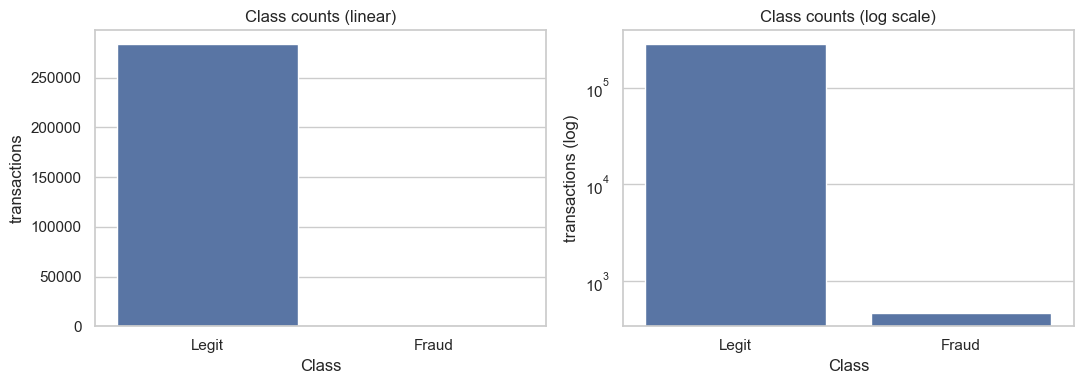

In [21]:
counts = df["Class"].value_counts().sort_index()
fraud_rate = counts[1] / counts.sum()
print(f"Legitimate (0): {counts[0]:,}")
print(f"Fraud      (1): {counts[1]:,}")
print(f"Fraud rate    : {fraud_rate:.4%}  (~1 fraud per {int(round(1/fraud_rate)):,} transactions)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=counts.index.map({0: "Legit", 1: "Fraud"}), y=counts.values, ax=ax[0])
ax[0].set(title="Class counts (linear)", ylabel="transactions")
sns.barplot(x=counts.index.map({0: "Legit", 1: "Fraud"}), y=counts.values, ax=ax[1])
ax[1].set_yscale("log")
ax[1].set(title="Class counts (log scale)", ylabel="transactions (log)")
plt.tight_layout(); plt.show()

The fraud class is ~1 in 580 transactions. This single fact drives every later
choice: stratified splitting, class-weighted training, threshold tuning, and
PR-AUC-based selection.

### 3.2 Transaction `Amount` by class

Fraud and legitimate transactions can differ in amount. We compare distributions
on a log scale (amounts are heavily right-skewed and include 0).

          mean     50%         max
Class                             
0      88.4136 22.0000 25,691.1600
1     123.8719  9.8200  2,125.8700


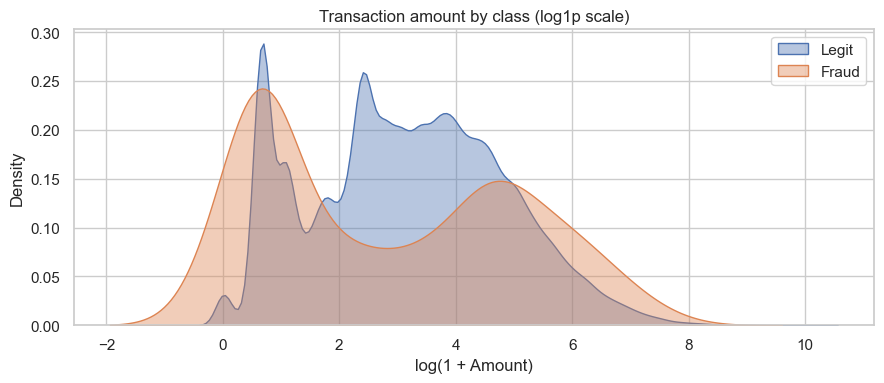

In [22]:
print(df.groupby("Class")["Amount"].describe()[["mean", "50%", "max"]])

fig, ax = plt.subplots(figsize=(9, 4))
for cls, label in [(0, "Legit"), (1, "Fraud")]:
    sns.kdeplot(np.log1p(df.loc[df.Class == cls, "Amount"]),
                label=label, fill=True, alpha=0.4, ax=ax)
ax.set(title="Transaction amount by class (log1p scale)", xlabel="log(1 + Amount)")
ax.legend(); plt.tight_layout(); plt.show()

### 3.3 Which PCA features separate the classes?

`V1`–`V28` are anonymised, so we can't name them — but we can see which carry the
strongest linear signal by correlating each with the target.

Top 10 features by |correlation| with fraud:
V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V11    0.1491
V4     0.1293
V18   -0.1053
Name: Class, dtype: float64


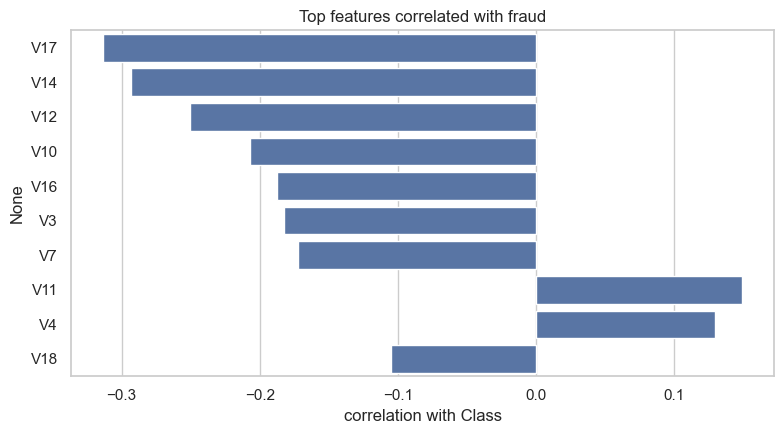

In [23]:
corr = df.corr(numeric_only=True)["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
top = corr.head(10)
print("Top 10 features by |correlation| with fraud:")
print(top)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=top.values, y=top.index, ax=ax)
ax.set(title="Top features correlated with fraud", xlabel="correlation with Class")
plt.tight_layout(); plt.show()

A handful of PCA components (e.g. `V14`, `V4`, `V11`, `V12`, `V17`) carry most of
the linear signal — encouraging for even a simple linear baseline.

## 4. Preprocessing & splitting

* **Split:** stratified **60 / 20 / 20** train / validation / test. Stratifying
  on `Class` keeps the fraud proportion identical in every fold — critical with
  so few positives. The **test set is touched only once**, at the very end.
* **Scaling:** `V1`–`V28` are already PCA outputs (centred, comparable scale);
  only `Time` and `Amount` are on raw scales. Linear models are
  scale-sensitive, so Logistic Regression gets a `StandardScaler` inside a
  `Pipeline` (fit on training data only — no leakage). Tree-based models are
  scale-invariant and receive the raw features.

In [24]:
X_train, X_val, X_test, y_train, y_val, y_test = dataio.make_splits(
    df, test_size=0.2, val_size=0.2, random_state=RANDOM_STATE
)

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:>5}: {len(y):>7,} rows | fraud {int(y.sum()):>4} ({y.mean():.4%})")

features = list(X_train.columns)
# Imbalance ratio used by boosting models to up-weight the positive class.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight (neg/pos) = {scale_pos_weight:.1f}")

train: 170,235 rows | fraud  284 (0.1668%)
  val:  56,745 rows | fraud   94 (0.1657%)
 test:  56,746 rows | fraud   95 (0.1674%)

scale_pos_weight (neg/pos) = 598.4


## 5. Baseline — Logistic Regression

A transparent linear baseline. `class_weight="balanced"` re-weights the loss so
the rare fraud class is not ignored. We report metrics on the **validation** set
at the default 0.5 threshold for now (threshold tuning comes in section 8).

In [25]:
results_val = {}   # model name -> metrics dict (validation, default threshold)
proba_val = {}     # model name -> predicted fraud probabilities on validation
fitted = {}        # model name -> fitted estimator

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

p = logreg.predict_proba(X_val)[:, 1]
proba_val["LogReg"], fitted["LogReg"] = p, logreg
results_val["LogReg"] = scoring.evaluate(y_val, p, threshold=0.5)
results_val["LogReg"]

{'threshold': 0.5,
 'pr_auc': 0.7876165501786713,
 'roc_auc': 0.9790382284664183,
 'precision': 0.05379746835443038,
 'recall': 0.9042553191489362,
 'f1': 0.1015531660692951,
 'tp': 85,
 'fp': 1495,
 'fn': 9,
 'tn': 55156}

## 6. Tree ensemble — Random Forest

A non-linear bagged model, again with balanced class weights. `n_jobs=-1` uses
all cores.

In [26]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

p = rf.predict_proba(X_val)[:, 1]
proba_val["RandomForest"], fitted["RandomForest"] = p, rf
results_val["RandomForest"] = scoring.evaluate(y_val, p, threshold=0.5)
results_val["RandomForest"]

{'threshold': 0.5,
 'pr_auc': 0.8713511479187963,
 'roc_auc': 0.9628527148494496,
 'precision': 0.898876404494382,
 'recall': 0.851063829787234,
 'f1': 0.8743169398907104,
 'tp': 80,
 'fp': 9,
 'fn': 14,
 'tn': 56642}

## 7. Gradient boosting — XGBoost & LightGBM

Gradient-boosted trees are the usual strong performers on tabular data. Instead
of `class_weight`, boosting handles imbalance via `scale_pos_weight` (XGBoost)
and `class_weight="balanced"` / `is_unbalance` (LightGBM), set from the training
imbalance ratio computed above. These run on CPU (`hist`); no GPU is required
for a dataset this size.

In [27]:
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.1, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train, y_train)
p = xgb.predict_proba(X_val)[:, 1]
proba_val["XGBoost"], fitted["XGBoost"] = p, xgb
results_val["XGBoost"] = scoring.evaluate(y_val, p, threshold=0.5)
print("XGBoost :", {k: round(v, 4) for k, v in results_val["XGBoost"].items()})

lgbm = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm.fit(X_train, y_train)
p = lgbm.predict_proba(X_val)[:, 1]
proba_val["LightGBM"], fitted["LightGBM"] = p, lgbm
results_val["LightGBM"] = scoring.evaluate(y_val, p, threshold=0.5)
print("LightGBM:", {k: round(v, 4) for k, v in results_val["LightGBM"].items()})

XGBoost : {'threshold': 0.5, 'pr_auc': 0.8851, 'roc_auc': 0.9779, 'precision': 0.9302, 'recall': 0.8511, 'f1': 0.8889, 'tp': 80, 'fp': 6, 'fn': 14, 'tn': 56645}
LightGBM: {'threshold': 0.5, 'pr_auc': 0.8843, 'roc_auc': 0.9793, 'precision': 0.963, 'recall': 0.8298, 'f1': 0.8914, 'tp': 78, 'fp': 3, 'fn': 16, 'tn': 56648}


## 8. Imbalance handling: model selection, threshold tuning & SMOTE

### 8.1 Select the model by PR-AUC (validation)

PR-AUC is threshold-independent, so it's the fair way to pick the best *ranker*
before we worry about an operating point.

Validation metrics (default 0.5 threshold), ranked by PR-AUC:


,pr_auc,roc_auc,recall,precision,f1
XGBoost,0.8851,0.9779,0.8511,0.9302,0.8889
LightGBM,0.8843,0.9793,0.8298,0.9630,0.8914
RandomForest,0.8714,0.9629,0.8511,0.8989,0.8743
LogReg,0.7876,0.9790,0.9043,0.0538,0.1016



Selected model: XGBoost (PR-AUC = 0.8851)


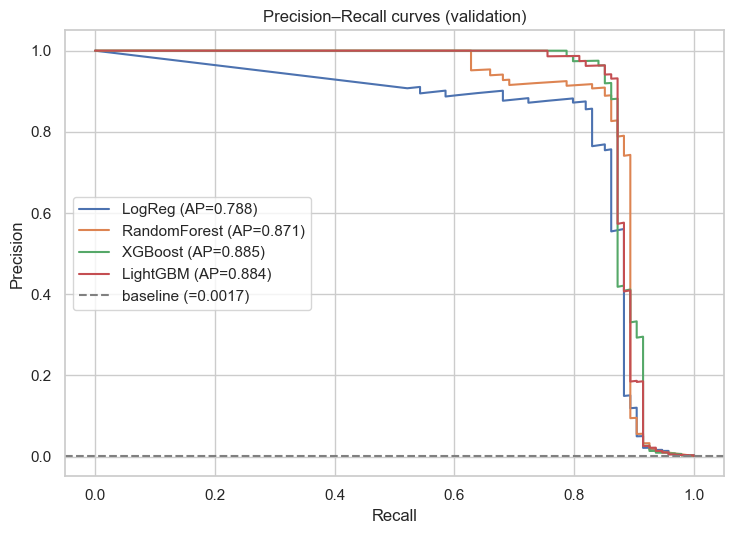

In [28]:
val_summary = (pd.DataFrame(results_val).T[["pr_auc", "roc_auc", "recall", "precision", "f1"]]
               .sort_values("pr_auc", ascending=False))
print("Validation metrics (default 0.5 threshold), ranked by PR-AUC:")
display(val_summary)

best_name = val_summary.index[0]
best_model = fitted[best_name]
print(f"\nSelected model: {best_name} (PR-AUC = {val_summary.loc[best_name, 'pr_auc']:.4f})")

# PR curves for all models
from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for name, p in proba_val.items():
    prec, rec, _ = precision_recall_curve(y_val, p)
    ax.plot(rec, prec, label=f"{name} (AP={results_val[name]['pr_auc']:.3f})")
ax.axhline(y_val.mean(), ls="--", c="grey", label=f"baseline (={y_val.mean():.4f})")
ax.set(title="Precision–Recall curves (validation)", xlabel="Recall", ylabel="Precision")
ax.legend(); plt.tight_layout(); plt.show()

### 8.2 Threshold tuning

The default 0.5 cut-off is arbitrary. We choose the threshold on the
**validation** set (never the test set) by maximising **F2** — the F-beta with
`beta=2`, which weights recall twice as heavily as precision because missing
fraud is the more expensive error. We also show the threshold needed to hit a
fixed **90% recall** SLA for comparison.

In [29]:
best_p_val = proba_val[best_name]
thr_f2, f2_at = scoring.best_threshold(y_val, best_p_val, beta=2.0)
thr_recall90 = scoring.threshold_for_recall(y_val, best_p_val, target_recall=0.90)

print(f"{best_name} threshold choices (tuned on validation):")
print(f"  F2-optimal threshold : {thr_f2:.4f}  (F2 = {f2_at:.4f})")
print(f"  90%-recall threshold : {thr_recall90:.4f}")

for label, thr in [("default 0.50", 0.5), ("F2-optimal", thr_f2), ("90% recall", thr_recall90)]:
    m = scoring.evaluate(y_val, best_p_val, threshold=thr)
    print(f"  [{label:>11} @ {thr:.3f}]  recall={m['recall']:.3f}  "
          f"precision={m['precision']:.3f}  f1={m['f1']:.3f}  (FP={m['fp']}, FN={m['fn']})")

CHOSEN_THRESHOLD = thr_f2   # operating point carried to the final test evaluation

XGBoost threshold choices (tuned on validation):
  F2-optimal threshold : 0.1258  (F2 = 0.8742)
  90%-recall threshold : 0.0022
  [default 0.50 @ 0.500]  recall=0.851  precision=0.930  f1=0.889  (FP=6, FN=14)
  [ F2-optimal @ 0.126]  recall=0.872  precision=0.882  f1=0.877  (FP=11, FN=12)
  [ 90% recall @ 0.002]  recall=0.904  precision=0.333  f1=0.487  (FP=170, FN=9)


### 8.3 Optional SMOTE — keep only if it actually helps

SMOTE synthesises new minority-class points to rebalance the *training* data. We
test it **only on the selected model**, fit on training data, and compare
validation PR-AUC against the class-weighted version. We keep it **only if it
improves** PR-AUC — resampling adds complexity and can hurt calibration, so it
must earn its place.

In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone

# Compare against a non-weighted variant of the same family, since SMOTE replaces
# class-weighting as the imbalance remedy.
if best_name == "XGBoost":
    base = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=5,
                         subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                         eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)
elif best_name == "LightGBM":
    base = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
elif best_name == "RandomForest":
    base = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  n_jobs=-1, random_state=RANDOM_STATE)
else:
    base = Pipeline([("scaler", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", clone(base)),
])
smote_pipe.fit(X_train, y_train)
p_smote = smote_pipe.predict_proba(X_val)[:, 1]

pr_auc_weighted = results_val[best_name]["pr_auc"]
pr_auc_smote = scoring.evaluate(y_val, p_smote)["pr_auc"]
print(f"Validation PR-AUC | class-weighted {best_name}: {pr_auc_weighted:.4f}")
print(f"Validation PR-AUC | SMOTE + {best_name}      : {pr_auc_smote:.4f}")

USE_SMOTE = pr_auc_smote > pr_auc_weighted
if USE_SMOTE:
    best_model = smote_pipe
    best_p_val = p_smote
    thr_f2, _ = scoring.best_threshold(y_val, best_p_val, beta=2.0)
    CHOSEN_THRESHOLD = thr_f2
    print(f"\n=> SMOTE improves PR-AUC; adopting it. New F2 threshold = {CHOSEN_THRESHOLD:.4f}")
else:
    print("\n=> SMOTE does not improve PR-AUC; keeping the simpler class-weighted model.")

Validation PR-AUC | class-weighted XGBoost: 0.8851
Validation PR-AUC | SMOTE + XGBoost      : 0.8841

=> SMOTE does not improve PR-AUC; keeping the simpler class-weighted model.


## 9. Final evaluation on the held-out test set

Now — and only now — we touch the test set, using the model and threshold fixed
on validation. This is the unbiased estimate of production performance.

FINAL MODEL: XGBoost  @ threshold 0.1258

     pr_auc: 0.8232
    roc_auc: 0.9758
     recall: 0.8000
  precision: 0.8837
         f1: 0.8398

  Confusion: TP=76  FP=10  FN=19  TN=56,641


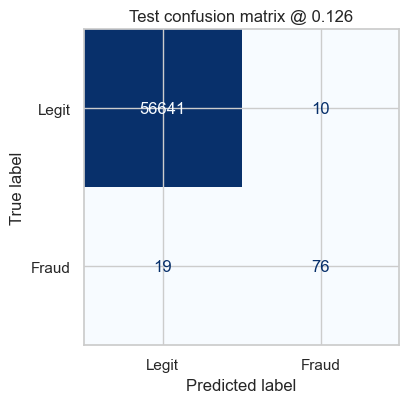

In [35]:
test_proba = best_model.predict_proba(X_test)[:, 1]
test_metrics = scoring.evaluate(y_test, test_proba, threshold=CHOSEN_THRESHOLD)

print(f"FINAL MODEL: {best_name}{' + SMOTE' if USE_SMOTE else ''}  @ threshold {CHOSEN_THRESHOLD:.4f}\n")
for k in ["pr_auc", "roc_auc", "recall", "precision", "f1"]:
    print(f"  {k:>9}: {test_metrics[k]:.4f}")
print(f"\n  Confusion: TP={test_metrics['tp']}  FP={test_metrics['fp']}  "
      f"FN={test_metrics['fn']}  TN={test_metrics['tn']:,}")

from sklearn.metrics import ConfusionMatrixDisplay
y_pred = (test_proba >= CHOSEN_THRESHOLD).astype(int)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Legit", "Fraud"], cmap="Blues",
    colorbar=False, ax=ax)
ax.set_title(f"Test confusion matrix @ {CHOSEN_THRESHOLD:.3f}")
plt.tight_layout(); plt.show()

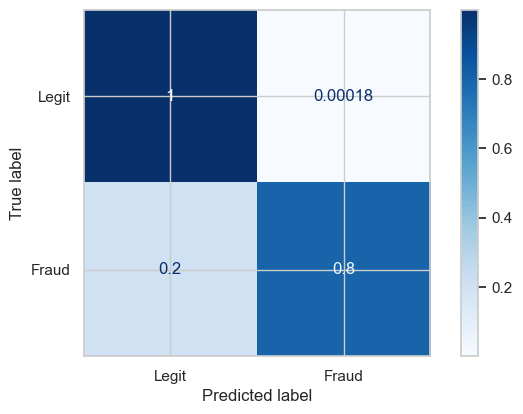

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    display_labels=["Legit", "Fraud"],
    cmap="Blues",
)

### 9.1 Top-K review analysis (Precision@K / Recall@K)

Fraud teams work a fixed daily budget of manual reviews. If we could review only
the *K* highest-risk transactions in the test window, how much fraud would we
catch and how clean would that queue be? This reframes the model as a ranking
tool, independent of any single threshold.

Test set holds 95 frauds among 56,746 transactions.


,k,frauds_caught,precision_at_k,recall_at_k
0,50,49,0.9800,0.5158
1,100,77,0.7700,0.8105
2,200,80,0.4000,0.8421
3,500,81,0.1620,0.8526
4,1000,83,0.0830,0.8737


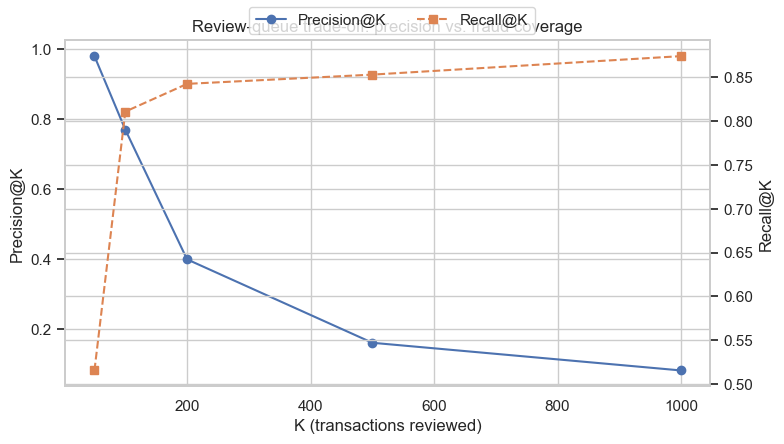

In [32]:
total_fraud_test = int(y_test.sum())
rows = [scoring.topk_review(y_test, test_proba, k) for k in (50, 100, 200, 500, 1000)]
topk_df = pd.DataFrame(rows)
print(f"Test set holds {total_fraud_test} frauds among {len(y_test):,} transactions.")
display(topk_df)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(topk_df["k"], topk_df["precision_at_k"], "o-", color="C0", label="Precision@K")
ax1.set(xlabel="K (transactions reviewed)", ylabel="Precision@K")
ax2 = ax1.twinx()
ax2.plot(topk_df["k"], topk_df["recall_at_k"], "s--", color="C1", label="Recall@K")
ax2.set_ylabel("Recall@K")
ax1.set_title("Review-queue trade-off: precision vs. fraud coverage")
fig.legend(loc="upper center", ncol=2); plt.tight_layout(); plt.show()

## 10. Model comparison & recommendation

The table below combines validation PR-AUC (the selection metric) with each
model's behaviour at its **own F2-tuned threshold on validation**, so the
comparison reflects a sensibly chosen operating point rather than the arbitrary
0.5 default.

In [33]:
comparison_rows = []
for name, p in proba_val.items():
    thr, _ = scoring.best_threshold(y_val, p, beta=2.0)
    m = scoring.evaluate(y_val, p, threshold=thr)
    comparison_rows.append({
        "model": name, "val_pr_auc": m["pr_auc"], "val_roc_auc": m["roc_auc"],
        "tuned_threshold": thr, "recall": m["recall"],
        "precision": m["precision"], "f1": m["f1"],
    })
comparison = (pd.DataFrame(comparison_rows).set_index("model")
              .sort_values("val_pr_auc", ascending=False))
display(comparison.style.format("{:.4f}").background_gradient(subset=["val_pr_auc"], cmap="Greens"))

,val_pr_auc,val_roc_auc,tuned_threshold,recall,precision,f1
model,,,,,,
XGBoost,0.8851,0.9779,0.1258,0.8723,0.8817,0.8770
LightGBM,0.8843,0.9793,0.0098,0.8723,0.9318,0.9011
RandomForest,0.8714,0.9629,0.4763,0.8617,0.8901,0.8757
LogReg,0.7876,0.9790,0.9997,0.8617,0.7570,0.8060


### Recommendation

*(Numbers above are produced at run time; the guidance below interprets them.)*

* **Selection:** choose the model with the highest **validation PR-AUC** — in
  practice the gradient-boosted trees (XGBoost / LightGBM) lead on this dataset,
  with Random Forest close behind and Logistic Regression a respectable,
  fully-interpretable baseline.
* **Operating point:** deploy the boosted model at its **F2-tuned threshold**,
  which favours recall (catching fraud) over precision. The confusion matrix and
  Precision@K analysis above quantify the analyst-workload cost of that choice.
* **Imbalance handling:** **class weighting + threshold tuning** is the simple,
  robust default. SMOTE is adopted in section 8.3 *only* if it measurably
  improves validation PR-AUC.
* **Practicality:** the model trains in seconds on CPU and scores in
  milliseconds, so no GPU is needed for this dataset size.

> Scope note: `V1`–`V28` are PCA features from one 2-day 2013 window, so absolute
> numbers won't transfer to another portfolio. The **methodology** — stratified
> splits, PR-AUC selection, explicit threshold tuning, top-K review framing — is
> what carries over.

## 11. Inference: a reusable fraud-risk scorer

We wrap the final model, its feature order, and the chosen threshold into a
`FraudScorer` (see `src/scoring.py`) and persist it with `joblib`. The same
bundle powers `batch_score.py` and the optional `app.py` API, so scoring is
identical everywhere.

In [34]:
scorer = scoring.FraudScorer(
    model=best_model,
    features=features,
    threshold=float(CHOSEN_THRESHOLD),
    metadata={
        "model_name": best_name + (" + SMOTE" if USE_SMOTE else ""),
        "selection_metric": "PR-AUC",
        "test_pr_auc": round(test_metrics["pr_auc"], 4),
        "test_recall": round(test_metrics["recall"], 4),
        "test_precision": round(test_metrics["precision"], 4),
        "random_state": RANDOM_STATE,
    },
)
saved_path = scorer.save("models/fraud_scorer.joblib")
print(f"Saved scorer -> {saved_path}")
print("Metadata:", scorer.metadata)

# Demo: score a sample of transactions (mix of known fraud + legit) and show output.
sample = pd.concat([
    X_test[y_test == 1].head(3),
    X_test[y_test == 0].head(3),
])
scored = scorer.score_frame(sample)[
    ["Amount", "fraud_probability", "risk_score", "risk_band", "is_flagged"]
]
scored.insert(0, "true_label", y_test.loc[sample.index].values)
display(scored)

Saved scorer -> models/fraud_scorer.joblib
Metadata: {'model_name': 'XGBoost', 'selection_metric': 'PR-AUC', 'test_pr_auc': 0.8232, 'test_recall': 0.8, 'test_precision': 0.8837, 'random_state': 42}


,true_label,Amount,fraud_probability,risk_score,risk_band,is_flagged
115676,1,76.9400,0.9986,999,High,1
95238,1,"1,354.2500",0.9999,1000,High,1
239334,1,1.0000,0.0034,3,Low,0
86249,0,11.5000,0.0000,0,Low,0
250634,0,1.9400,0.0000,0,Low,0
20163,0,91.2800,0.0000,0,Low,0


### Using the saved model elsewhere

```bash
# Batch-score any CSV with the same columns and write results out:
uv run python batch_score.py --input data/raw/creditcard.csv --output reports/scored.csv

# Or serve it (optional, lightweight FastAPI):
uv run uvicorn app:app --reload
# then POST a transaction JSON to http://127.0.0.1:8000/score
```

The model bundle (`models/fraud_scorer.joblib`) is the single source of truth —
it carries the estimator, the exact feature order, and the operating threshold,
so the notebook, the batch script, and the API all score transactions
identically.